# Preamble

In [1]:
import numpy as np
import scipy.integrate as itg
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler

plt.style.use('dark_background')
mpl.rcParams['axes.prop_cycle'] = cycler(color=mpl.color_sequences['Pastel1'])
mpl.rcParams['figure.facecolor'] = 'xkcd:dark'
mpl.rcParams['axes.facecolor'] = 'none'

# Scalar ODE for eigenvalues

Bernoulli differential equation: $y' = y - y^3.$ If $y_0 \in {0, \pm 1}$ then $y = y_0.$ Otherwise substitute $v := y^{-2},$ get
$$v' = -2y^{-3} y' = -2 y^{-3} (y - y^3) = 2(1-v).$$
Then
$$1-v = 1-y^{-2} = C\exp(-2t)$$
so
$$y = \pm(1-C\exp(-2t))^{-1/2}.$$
In terms of initial conditions
$$C = 1-y_0^{-2}.$$
Finally
$$y = \frac{\operatorname{sgn} y_0}{\sqrt{1-(1-y_0^{-2})\exp(-2t)}} = \frac{y_0}{\sqrt{1 + (1-y_0^2)(\exp(-2t)-1)}} := \frac{y_0}{\sqrt{\Delta(t, y_0)}}.$$
This expression is valid for $t > t_* = \frac{1}{2} \log \left( 1 - y_0^{-2} \right)$ when $|y_0| > 1.$ If $|y_0| < 1,$ it is valid for all $t.$ This is equivalent to checking if the determinant $\Delta(t, y_0) > 0.$ Since ODE is autonomous, all solutions for various $t_0$ can be gotten by simple shifts.

In [2]:
def fun(t, y):
    return y * (1.0 - y * y)


def y_exact(t, y0):
    if y0 in (0.0, 1.0, -1.0): return np.full_like(t, y0)
    determinant = 1.0 + (1.0 - y0*y0) * np.expm1(-2.0*t)
    return y0 * np.where(
        determinant > 0.0,
        np.reciprocal(np.sqrt(determinant)),
        np.full_like(t, np.inf),
    )

# Naive RK and Euler

The first method is explicit Euler, and we will take advantage of `scipy`'s existing infrastructure for solving IVPs. Butcher tableau notation from the Hairer, Nørsett, Wanner book:
$$
\def\arraystretch{1.5}\begin{array}{c|c}
   C & A \\ \hline
     & B^T \\
\end{array} =
\def\arraystretch{1.0}\begin{array}{c|c}
   0      &  \\
   c_2    & a_{21} \\
   \vdots & \vdots & \ddots \\
   c_S    & a_{S1}   & \cdots & a_{S,S-1} \\
   \hline
          & b_1 & \cdots & b_{S-1} & b_S \\
\end{array}
$$
where for each stage $s = 1, \ldots, S,$ we find entry of $K = (k_1 \quad \cdots \quad k_S \quad k_{S+1})^T,$
$$
k_s = f\left(t_0 + c_s h\ ,\ y_0 + h \sum_{i=1}^{s-1} a_{si} k_i \right),
$$
and the result of the step is $y_1 = y_0 + h B^T K.$ The next slope $k_{S+1} = f(t_0 + h, y_1)$ is also computed.

In [3]:
from scipy.integrate._ivp.rk import RungeKutta, rk_step

class RK21(RungeKutta):
    order = 1
    error_estimator_order = 2
    n_stages = 1
    C = np.array([0.0])
    A = np.array([[0.0]])
    B = np.array([1.0])
    E = np.array([-1.0, 1.0])
    P = np.array([[1.0,  1, -1],
                  [  0, -1,  1]])


In [4]:
class NaiveRungeKutta(RungeKutta):
    def __init__(self, fun, t0, y0, t_bound, num_steps=50,
                 rtol=1e-3, atol=1e-6, vectorized=False, **extraneous):
        itg._ivp.common.warn_extraneous(extraneous)

        self.num_steps = num_steps
        self.steps_taken = 0
        self.step_ts = np.linspace(t0, t_bound, num_steps + 1)
        max_step = np.max(np.abs(self.step_ts[1:] - self.step_ts[:-1]))
        first_step = np.abs(self.step_ts[1] - self.step_ts[0])

        super().__init__(fun, t0, y0, t_bound, max_step=max_step,
                 rtol=rtol, atol=atol, vectorized=vectorized,
                 first_step=first_step)

    def _step_impl(self):
        t = self.t
        y = self.y

        rtol = self.rtol
        atol = self.atol

        min_step = 10 * np.abs(np.nextafter(t, self.direction * np.inf) - t)

        t_new = self.step_ts[self.steps_taken + 1]
        h = t_new - t
        h_abs = np.abs(h)

        if h_abs < min_step:
            return False, self.TOO_SMALL_STEP

        y_new, f_new = rk_step(self.fun, t, y, self.f, h, self.A,
                                self.B, self.C, self.K)
        scale = atol + np.maximum(np.abs(y), np.abs(y_new)) * rtol
        error_norm = self._estimate_error_norm(self.K, h, scale)

        self.h_previous = h
        self.y_old = y

        self.t = t_new
        self.y = y_new

        self.h_abs = h_abs
        self.f = f_new
        self.steps_taken += 1

        return True, None


class NaiveRK21(NaiveRungeKutta, RK21):
    pass
class NaiveRK23(NaiveRungeKutta, itg.RK23):
    pass

# First cut of scalar ODE

/tmp/ipykernel_5512/2388363998.py:36: RuntimeWarning: divide by zero encountered in log
  ]).T, np.log(info['global_error'][:-1]))


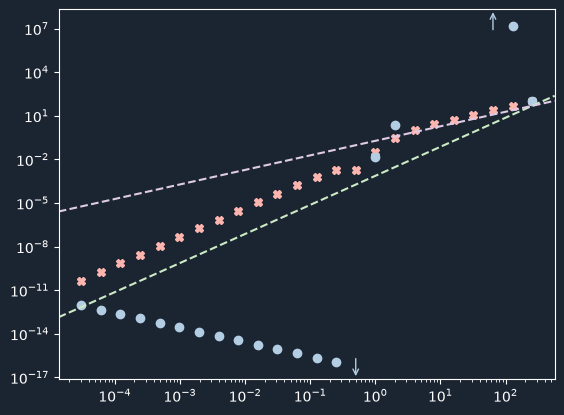

(array([nan, nan]),
 array([nan]),
 np.int32(2),
 array([25.87116246,  4.08755578]))

In [5]:

def ivp_explicit_euler(f, tbounds, u0, num_steps):
    t0, t1 = tbounds
    h = (t1 - t0) / num_steps

    ts = np.linspace(t0, t1, num_steps + 1)
    us = np.array([u := u0, *(u := u + h * f(t, u) for t in ts[:-1])])
    return (ts, us)


def ivp_explicit_euler_error_vs_step_size(f, tbounds, u0, u_exact, norm, num_stepss):
    t0, t1 = tbounds

    @np.vectorize(otypes=[[('step_size', float),
                           ('local_error', float),
                           ('global_error', float)]])
    def analysis_info(num_steps):
        t, u_est = ivp_explicit_euler(f, tbounds, u0, num_steps)
        step_size = (t1 - t0) / num_steps
        local_error = norm(u_exact(t[1], u0) - u_est[1])
        global_error = norm(u_exact(t[-1], u0) - u_est[-1])
        return (step_size, local_error, global_error)

    error_analysis_info = analysis_info(num_stepss)
    error_analysis_info.sort(order=['step_size'])
    return error_analysis_info


u0 = 0.5
tbounds = (0.0, 256.0)
info = ivp_explicit_euler_error_vs_step_size(
    fun, tbounds, u0, y_exact, np.abs, 1 << np.arange(24))

gerr_lstsq_res = np.linalg.lstsq(np.array([
        np.log(info['step_size'][:-1]),
        np.ones_like(info['step_size'][:-1]),
    ]).T, np.log(info['global_error'][:-1]))



fig, ax = plt.subplots()
ax1 = ax
ax2 = ax
fig.subplots_adjust(hspace=0.05)

ax1.set_xscale('log')
ax1.set_yscale('log')
# ax2.set_yscale('log')
# ax1.spines.bottom.set_visible(False)
# ax2.spines.top.set_visible(False)
# ax1.xaxis.tick_top()
# d = .5
# kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
#               linestyle="none", color='white', mec='white', mew=1, clip_on=False)
# ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
# ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)


ax1.plot(info["step_size"], info["local_error"], "C0X")

gerror_nan_mask = np.isnan(info["global_error"])
step_sizes_where_nan = info[gerror_nan_mask]
ginfo = info[np.logical_not(gerror_nan_mask)]

partition_idx = 8
step_sizes_where_zero = ginfo[ginfo["global_error"] == 0.0]["step_size"]

num_big_cut = 1

if num_big_cut > 0:
    big_indices = np.argpartition(ginfo["global_error"], -num_big_cut)[-num_big_cut:]
    big_cutoff = np.min(ginfo["global_error"][big_indices])
    step_sizes_where_big = ginfo["step_size"][big_indices]
    plotted_ginfo = ginfo[ginfo["global_error"] < big_cutoff]
else:
    step_sizes_where_big = []
    plotted_ginfo = ginfo

hs = plotted_ginfo["step_size"]
Es = plotted_ginfo["global_error"]
ax1.plot(hs[partition_idx:], Es[partition_idx:], "C1o")
ax2.plot(hs[:partition_idx], Es[:partition_idx], "C1o")

y_bottom1, y_top1 = ax1.get_ylim()
y_bottom2, y_top2 = ax2.get_ylim()

arrow_len1 = np.exp((1.0/16) * np.log(y_top1 / y_bottom1))
arrow_len2 = np.exp((1.0/16) * np.log(y_top2 / y_bottom2))

for h in step_sizes_where_zero:
    ax2.annotate("", xytext=(h, y_bottom2 * arrow_len2), xy=(h, y_bottom2),
                arrowprops=dict(arrowstyle="->", color="C1"))

for h in step_sizes_where_big:
    ax1.annotate("", xytext=(h, y_top1 / arrow_len1), xy=(h, y_top1),
                arrowprops=dict(arrowstyle="->", color="C1"))

sample_h = plotted_ginfo["step_size"][-1]
len_t = tbounds[1] - tbounds[0]
avg_d2udt2_times_len_t = np.abs(fun(tbounds[1], y_exact(tbounds[1], u0)) - fun(tbounds[0], u0))
avg_d2udt2 = avg_d2udt2_times_len_t / len_t

local_ref_pt1 = np.array([sample_h, 0.5 * avg_d2udt2_times_len_t * sample_h * sample_h / len_t])
local_ref_pt2 = local_ref_pt1 * np.array([0.5, 0.25])
ax.axline(local_ref_pt1, local_ref_pt2, color="C2", linestyle='--')

global_ref_pt1 = np.array([sample_h, 0.5 * avg_d2udt2_times_len_t * sample_h])
global_ref_pt2 = 0.5 * global_ref_pt1
ax.axline(global_ref_pt1, global_ref_pt2, color="C3", linestyle='--')

plt.show()
gerr_lstsq_res

# Matrix differential equations

In [6]:
def make_polar_factor_flow_fun(out_dim):
    def polar_factor_flow_fun(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        XTX = X.T @ X
        return np.reshape(X @ (np.eye(*np.shape(XTX)) - XTX), shape=(-1,))
    return polar_factor_flow_fun

def make_polar_factor_flow_jac(out_dim):
    def polar_factor_flow_jac(_t, vecX):
        X = np.reshape(vecX, shape=(out_dim, -1))
        n, m = X.shape
        dac_dbd = np.multiply.outer(np.eye(n), np.eye(m))
        dbd_Xaj_Xcj = np.multiply.outer(np.eye(m), X @ X.T)
        dac_Xkb_Xkd = np.multiply.outer(np.eye(n), X.T @ X)
        Xad_Xcb = np.multiply.outer(X, X)

        return (
            np.transpose(dac_dbd, (0, 2, 1, 3))
            - np.transpose(dbd_Xaj_Xcj, (2, 0, 3, 1))
            - np.transpose(dac_Xkb_Xkd, (0, 2, 1, 3))
            - np.transpose(Xad_Xcb, (0, 3, 2, 1))
        ).reshape((n * m, n * m))
    return polar_factor_flow_jac

def polar_factor_flow_exact_helped(t, sv0s, U, V):
    svs = np.array([y_exact(t, sv0) for sv0 in sv0s])
    return U @ (svs * V.T)


polar_factor_flow_exact_helped(1.0, np.array([0.25, 1.0, 8.0]), np.eye(3), np.eye(3))

array([[0.57448222, 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 1.0741025 ]])

# Graph of Flow Lines and Euler Polygons

For plotting purposes, assume 1:1 scale. We want to find curves which intersect the family of curves orthogonally. They are the parametric curves $(x(y), y)$ where $x'(y) = -f(y) = y^3 - y.$ Integrating yields:

$$ x(y) = \frac{y^4}{4} - \frac{y^2}{2} + x_0 = \left(\frac{y^2}{2} - 1\right) \frac{y^2}{2} + x_0. $$

The arc-length of this curve from $(x(0), 0)$ to $(x(y), y)$ is:

$$ s(y) = \int_0^y \sqrt{f^2(u) + 1}\ du = \int_0^y \sqrt{f^2(u) + 1}\ du. $$

Inverse of this function $y(s)$ satisfies the following ODE with $y(0) = 0$:

$$ y'(s) = \frac{1}{s'(y(s))} = \frac{1}{\sqrt{f^2(y) + 1}}. $$

In [7]:
def plot_flow_lines(ax: plt.Axes, ts, axis_t0):
    def x_fun(y):
        y = 0.5 * y * y
        return (y - 1.0) * y

    y_bottom, y_top = ax.get_ylim()
    L, _ = itg.quad(lambda u: np.sqrt(fun(0.0, u)**2 + 1.0), y_bottom, y_top)
    y0s = itg.solve_ivp(
        lambda t, y: np.reciprocal(np.sqrt(fun(0.0, y)**2 + 1.0)),
        (0.0, L),
        [0.0],
        t_eval=np.linspace(0.0, L, 17),
    ).y[0]
    t0s = x_fun(y0s) + axis_t0
    ax.plot(t0s, y0s, ".")

    for t0, y0 in np.column_stack((t0s, y0s)):
        ye = y_exact(ts - t0, y0)
        ax.plot(ts, ye, linewidth='0.125')

In [69]:
np.info(np.random.Generator.power)

power(a, size=None)

Draws samples in [0, 1] from a power distribution with positive
exponent a - 1.

Also known as the power function distribution.

Parameters
----------
a : float or array_like of floats
    Parameter of the distribution. Must be non-negative.
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  If size is ``None`` (default),
    a single value is returned if ``a`` is a scalar.  Otherwise,
    ``np.array(a).size`` samples are drawn.

Returns
-------
out : ndarray or scalar
    Drawn samples from the parameterized power distribution.

Raises
------
ValueError
    If a <= 0.

Notes
-----
The probability density function is

.. math:: P(x; a) = ax^{a-1}, 0 \le x \le 1, a>0.

The power function distribution is just the inverse of the Pareto
distribution. It may also be seen as a special case of the Beta
distribution.

It is used, for example, in modeling the over-reporting of insur

In [ ]:
from scipy.linalg import expm

rng = np.random.default_rng(666)

def random_SO(rng: np.random.Generator, n: int):
    mex = np.zeros((n, n))

    # https://dl.acm.org/doi/epdf/10.1145/377939.377946
    rot = rng.standard_normal(n * (n-1) // 2)
    normrot = np.linalg.vector_norm(rot)
    if normrot == 0.0: normrot = 1.0
    rot *= rng.uniform(0.0, 2 * np.pi) / normrot

    for i in range(n):
        for j in range(i+1, n):
            entry = rot[j - 1 + i * (2*n - i - 3) // 2]
            mex[i, j] = entry
            mex[j, i] = -entry

    return expm(mex)

def random_O(rng, n):
    U = random_SO(rng, n)
    if n > 0 and rng.integers(0, 2) == 1:
        U[:,0] *= -1.0
    return U

random_O(rng, 3)


array([[-0.44271552,  0.58933582, -0.67578566],
       [ 0.74111825,  0.66473545,  0.0941835 ],
       [ 0.5047244 , -0.45914059, -0.73105623]])

/tmp/ipykernel_3753/263605267.py:10: RuntimeWarning: invalid value encountered in sqrt
  np.reciprocal(np.sqrt(determinant)),


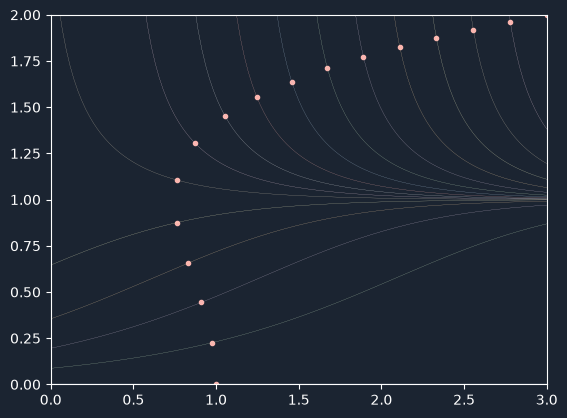

In [15]:
fig: plt.Figure
ax: plt.Axes
fig, ax = plt.subplots()

ax.set_xlim(0.0, 3.0)
ax.set_ylim(0.0, 2.0)

plot_flow_lines(ax, np.linspace(*ax.get_xlim(), 129), 1.0)

plt.show()